In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter, defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score

# Natural Language Processing with Disaster Tweets

This Jupyter Notwbook aims to classify tweets as either real disasters or not a disaster using Natural Language Processing (NLP) techniques and a Sequential Neural Network model.

## Project Overview and Challenge Description

The goal of this project is to build a machine learning model that can accurately predict whether a given tweet is about a real disaster or not. This is a binary text classification problem where we'll leverage the textual content of tweets, along with other metadata like keywords and locations, to make our predictions.

The primary challenge lies in the informal and often ambiguous nature of tweets. Distinguishing genuine disaster reports from casual mentions, jokes, or related news requires robust NLP techniques.

## Data Loading and Initial Inspection

We will load the three provided datasets: train.csv, test.csv, and sample_submission.csv. After loading, we'll perform an initial inspection to understand their structure, dimensions, and data types.

In [2]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Initial inspection
print("--- train_df Info ---")
train_df.info()
print("\n--- train_df Head ---")
print(train_df.head())
print("\n--- train_df Shape ---")
print(f"Rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")
print("\n--- train_df Missing Values ---")
print(train_df.isnull().sum())

print("--- test_df Info ---")
test_df.info()
print("\n--- test_df Head ---")
print(test_df.head())
print("\n--- test_df Shape ---")
print(f"Rows: {test_df.shape[0]}, Columns: {test_df.shape[1]}")
print("\n--- test_df Missing Values ---")
print(test_df.isnull().sum())

--- train_df Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

--- train_df Head ---
   id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       

## Exploratory Data Analysis and Visualizations

In this section, we'll explore the characteristics of our data through various visualizations. This will help us understand distributions, identify patterns, and detect potential issues like class imbalance.

### Target Variable Distribution

We will now visualize the distribution of the target variable in the training dataset to check for class imbalance.

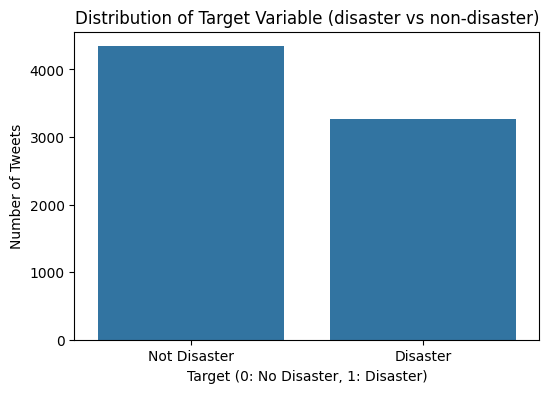


--- Target Variable Value Counts ---
target
0    4342
1    3271
Name: count, dtype: int64
Percentage of Disaster Tweets: 42.97%
Percentage of Non-Disaster Tweets: 57.03%


In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data = train_df)
plt.title('Distribution of Target Variable (disaster vs non-disaster)')
plt.xlabel('Target (0: No Disaster, 1: Disaster)')
plt.ylabel('Number of Tweets')
plt.xticks([0, 1], ['Not Disaster', 'Disaster'])
plt.show()

print("\n--- Target Variable Value Counts ---")
print(train_df['target'].value_counts())
print(f"Percentage of Disaster Tweets: {train_df['target'].value_counts(normalize=True)[1]*100:.2f}%")
print(f"Percentage of Non-Disaster Tweets: {train_df['target'].value_counts(normalize=True)[0]*100:.2f}%")


### Tweet Length Distribution

We'll analyze the distribution of tweet lengths by character count for both disaster and non-disaster tweets.

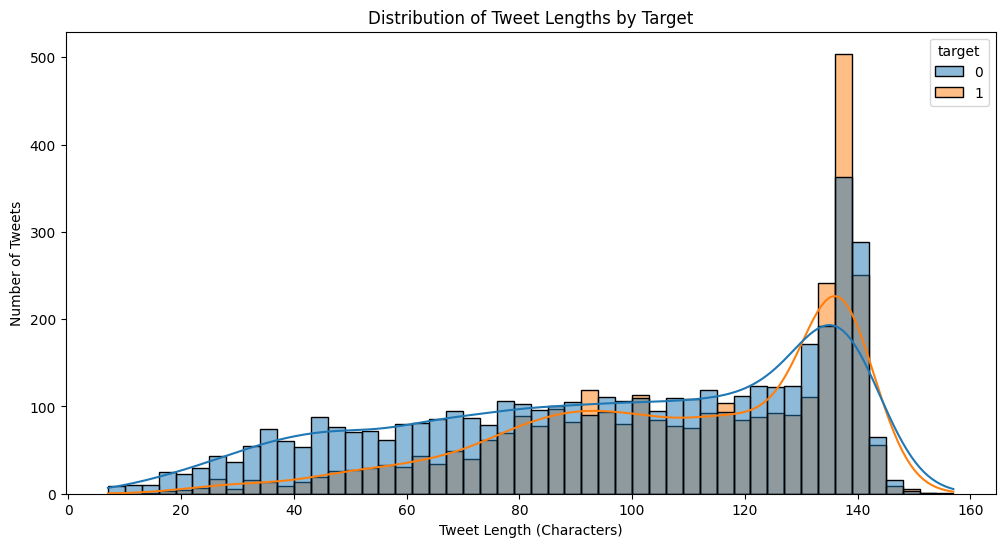


--- Descriptive Statistics of Tweet Lengths ---
         count        mean        std   min   25%    50%    75%    max
target                                                                
0       4342.0   95.706817  35.885924   7.0  68.0  101.0  130.0  157.0
1       3271.0  108.113421  29.309854  14.0  88.0  115.0  136.0  151.0


In [4]:
train_df['text_len'] = train_df['text'].apply(len)
test_df['text_len'] = test_df['text'].apply(len)

plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x='text_len', hue='target', kde=True, bins=50)
plt.title('Distribution of Tweet Lengths by Target')
plt.xlabel('Tweet Length (Characters)')
plt.ylabel('Number of Tweets')
plt.show()

print("\n--- Descriptive Statistics of Tweet Lengths ---")
print(train_df.groupby('target')['text_len'].describe())

### Top Keywords

Let's now look at the most frequent keywords in the training set.

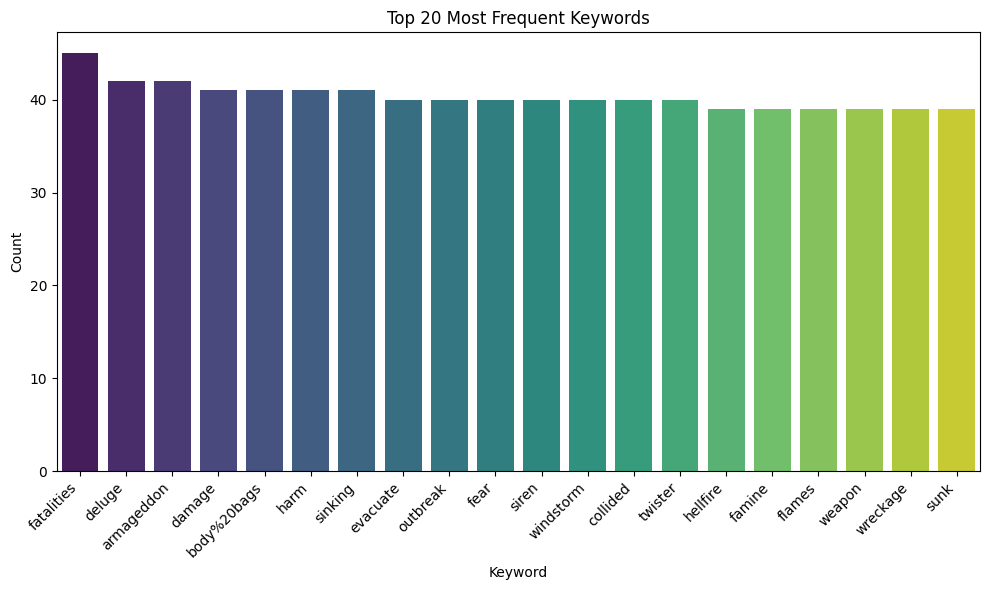

In [5]:
plt.figure(figsize=(10, 6))
top_keywords = train_df['keyword'].value_counts().nlargest(20)
plot_df_keywords = pd.DataFrame({
    'Keyword': top_keywords.index,
    'Count': top_keywords.values
})
sns.barplot(x='Keyword', y='Count', data=plot_df_keywords, palette='viridis', hue='Keyword', legend=False)
plt.title('Top 20 Most Frequent Keywords')
plt.xlabel('Keyword')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top Locations

Similarly, we can visualize the most frequent locations.

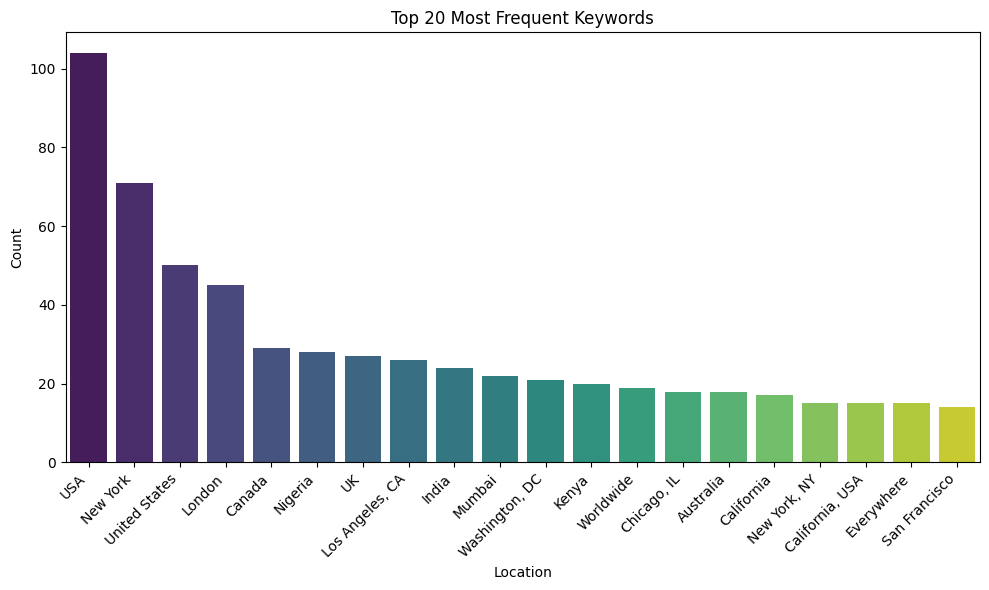

In [6]:
plt.figure(figsize=(10, 6))
top_locations = train_df['location'].value_counts().nlargest(20)
plot_df_locations = pd.DataFrame({
    'Location': top_locations.index,
    'Count': top_locations.values
})
sns.barplot(x='Location', y='Count', data=plot_df_locations, palette='viridis', hue='Location', legend=False)
plt.title('Top 20 Most Frequent Keywords')
plt.xlabel('Location')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Cleaning Procedures

Before we can use the text data for modeling, it needs to be cleaned and preprocessed. This involves several steps to normalize the text and remove noise.

In [7]:
# Combine train and test for consistent preprocessing
combined_df = pd.concat([train_df.drop('target', axis=1), test_df], ignore_index=True)

# Define a function for text cleaning
def clean_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'\[.*?\]', '', text) # Remove square brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>+', '', text) # Remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub(r'\n', '', text) # Remove newline characters
    text = re.sub(r'\w*\d\w*', '', text) # Remove words containing numbers
    text = re.sub(r'@\w+', '', text) # Remove mentions
    text = re.sub(r'#', '', text) # Remove hashtag symbol, keep word
    return text

# Apply the cleaning function
combined_df['cleaned_text'] = combined_df['text'].apply(clean_text)

# Tokenization and Stop Word Removal
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_and_clean(text):
    tokens = text.split() # Simple tokenization by space
    tokens = [word for word in tokens if word not in stop_words] # Remove stop words
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatization
    return " ".join(tokens)

combined_df['processed_text'] = combined_df['cleaned_text'].apply(tokenize_and_clean)

# Separate back into train and test
train_df['processed_text'] = combined_df.iloc[:len(train_df)]['processed_text']
test_df['processed_text'] = combined_df.iloc[len(train_df):]['processed_text']

print("\n--- Sample of Processed Text (Train) ---")
print(train_df[['text', 'processed_text']].head())


--- Sample of Processed Text (Train) ---
                                                text  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   
3  13,000 people receive #wildfires evacuation or...   
4  Just got sent this photo from Ruby #Alaska as ...   

                                      processed_text  
0         deed reason earthquake may allah forgive u  
1              forest fire near la ronge sask canada  
2  resident asked shelter place notified officer ...  
3  people receive wildfire evacuation order calif...  
4  got sent photo ruby alaska smoke wildfire pour...  


### Top Words after Preprocessing

Let's see the most frequently used words in our processed text for both disaster and non-disaster tweets.

<function matplotlib.pyplot.show(close=None, block=None)>

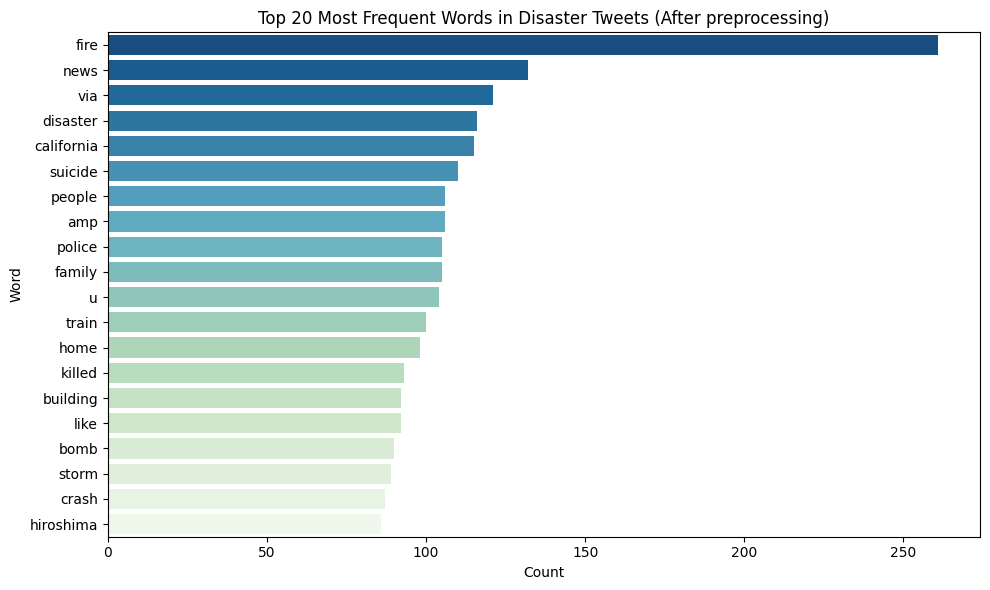

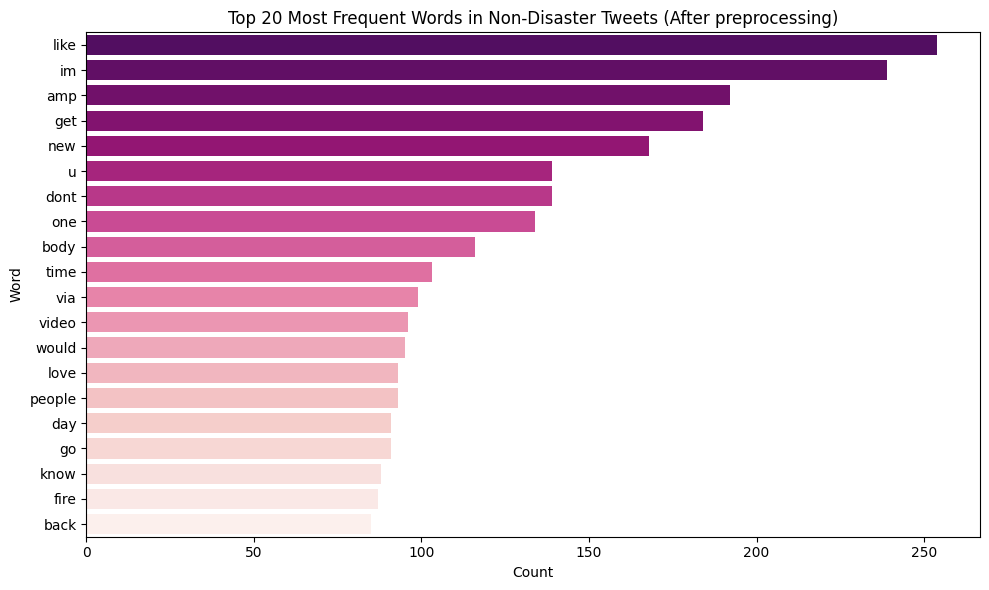

In [8]:
# Function to get most common words
def get_top_n_words(corpus, n=None):
    words = []
    for text in corpus:
        for word in text.split():
            words.append(word)
    return Counter(words).most_common(n)

# Top words in disaster tweets
disaster_words = get_top_n_words(train_df[train_df['target'] == 1]['processed_text'], 20)
df_disaster_words = pd.DataFrame(disaster_words, columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Word', data=df_disaster_words, palette='GnBu_r', hue='Word', legend=False)
plt.title('Top 20 Most Frequent Words in Disaster Tweets (After preprocessing)')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show

# Top words in non-disaster tweets
non_disaster_words = get_top_n_words(train_df[train_df['target'] == 0]['processed_text'], 20)
df_non_disaster_words = pd.DataFrame(non_disaster_words, columns=['Word', 'Count'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Word', data=df_non_disaster_words, palette='RdPu_r', hue='Word', legend=False)
plt.title('Top 20 Most Frequent Words in Non-Disaster Tweets (After preprocessing)')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show

## Plan of Analysis based on EDA

Based on this exploratory data analysis, we observe a slight imbalance in the target variable, with there being more non-disaster tweets than disaster tweets. It isn't too severe, but enough to keep in mind and make us consider techniques like using evaluation metrics such as F1-score, Precision, and Recall in addition to accuracy. We could also potentially implement class weights during model training if performance is impacted.

The crucial cleaning step of Text Preprocessing (such as lowercasing, removing URLs, punctuation, stopwords, and lemmatization) has been applied. This will help standardize the text and reduce noise.

### --Feature Engineering--

The processed_text columns will be the primary feature. This text will be converted into numerical representations suitable for neural networks. The keyword and location columns have missing values and high cardinality. For the initial network, we will focus primarily on the text. If performance suffers, we could consider imputing missing keyword and location values with a value of 'unknown'. Or one-hot encoding or embedding the features and concatenating them with the text embeddings. 

### --Model Architecture - Sequential Neural Network--

We'll build a sequential neural network given its effectiveness in handling sequential data like text. There will be an embedding layer as the first layer, converting vocabulary into dense vector representations. A recurrent/convolutional layer will follow that will learn patterns and dependencies within the tweet sequences. Next will be fully connected dense layers for classification. Then the output layer will give a single neuron with a sigmoid activation function for binary classification.

### --Training and Evaluation--

Split the training data into training and validation sets for monitoring overfitting. Train the model using the processed_text and target variables. Monitor performance using the metrics we think are important. Implement early stopping to prevent overfitting, and perform predictions on the test_df to generate the submission file.

## Text to Matrix Transformation

Before feeding our textual data into a neural network, it needs to be converted into a numerical matrix form. For this project, I'll use Tokenization and Padding for this.

### -Tokenization

Tokenization is the process of breaking down raw text into smaller units called tokens. These can be words, subwords, or even characters. For NLP, word-level tokenization is common, where each unique word becomes a token. A vocabulary is built from all unique tokens in the training dataset, and each token is assigned to an integer ID. It works by taking all unique words from the processed text in our training data to form the corpus, and a tokenizer object is used to fit the training texts to create a vocab and assign a unique integer index to each word. Words are typically ordered by how often they appear, and a special index is saved for padding or out-of-vocab words. Each tweet is then converted into a sequence of the integer IDs.

### -Padding

Neural networks require input sequences to have uniform length. Since tweets are obviously not all the same length, we need to pad shorter sequences and sometimes shorten longer sequences to a predefined max length. Choosing max sequence length is typically done based on the distribution of tweet lengths to cover most tweets without excessive padding. Sequences that fall short of max length are filled with a padding value at the end. Sequences that are too long get truncated.


This method is standard for preparing text data for deep learning models. It converts varying length tweets and text into fixed-sized numerical inputs that neural networks can process. The integer IDs are the input for an embedding layer, which then learns dense vector representations for each word.

In [9]:
def build_vocab(texts, min_freq=1, pad_token="<pad>", unk_token="<unk>"):
    word_counts = defaultdict(int)
    for text in texts:
        for word in text.split():
            word_counts[word] += 1

    sorted_words = sorted(word_counts.keys(), key=word_counts.get, reverse=True)

    word_to_idx = {pad_token: 0, unk_token: 1} # Reserve 0 for padding, 1 for unknown
    idx_to_word = {0: pad_token, 1: unk_token}
    
    for idx, word in enumerate(sorted_words):
        word_to_idx[word] = idx + 2 # Start actual words from index 2
        idx_to_word[idx + 2] = word
            
    return word_to_idx, idx_to_word

def text_to_sequence(text, word_to_idx, max_length, unk_token="<unk>"):
    unk_idx = word_to_idx.get(unk_token, 1) # Default to 1 if unk_token not found
    sequence = [word_to_idx.get(word, unk_idx) for word in text.split()]
    
    # Pad or truncate
    if len(sequence) < max_length:
        sequence = sequence + [word_to_idx["<pad>"]] * (max_length - len(sequence))
    elif len(sequence) > max_length:
        sequence = sequence[:max_length]
        
    return sequence

In [18]:
# Before converting to sequences, fill any NaN values with empty string
train_df['processed_text'] = train_df['processed_text'].fillna('')
test_df['processed_text'] = test_df['processed_text'].fillna('')

# Build a vocabulary from data
all_processed_texts = pd.concat([train_df['processed_text'], test_df['processed_text']], ignore_index=True)
word_to_idx, idx_to_word = build_vocab(all_processed_texts) # <--- THIS LINE IS MODIFIED
vocab_size = len(word_to_idx)

# Determine maximum sequence length
train_df['processed_text_len'] = train_df['processed_text'].apply(lambda x: len(x.split()))
max_length = int(train_df['processed_text_len'].quantile(0.95)) # Max sequence length of 95th percentile

print(f"Vocabulary Size: {vocab_size}")
print(f"Max Sequence Length (95th percentile): {max_length}")

Vocabulary Size: 15435
Max Sequence Length (95th percentile): 15


In [19]:
print("\n--- Diagnostic: Checking Processed Text and Vocabulary Mapping ---")
print(f"Number of NaN in train_df['processed_text'] after fillna: {train_df['processed_text'].isnull().sum()}")
print(f"Number of NaN in test_df['processed_text'] after fillna: {test_df['processed_text'].isnull().sum()}")

# Convert texts to sequences of integers
X_train_seq = [text_to_sequence(text, word_to_idx, max_length) for text in train_df['processed_text']]
X_test_seq = [text_to_sequence(text, word_to_idx, max_length) for text in test_df['processed_text']]

# Diagnostics
print("\n--- Diagnostic: Checking Test Sequences ---")
unique_tokens_in_test_sequences = set()
for seq in X_test_seq:
    unique_tokens_in_test_sequences.update(seq)
print(f"Number of unique token IDs in X_test_seq: {len(unique_tokens_in_test_sequences)}")
print(f"Unique token IDs found in X_test_seq: {sorted(list(unique_tokens_in_test_sequences))}")

print("\nFirst 5 X_test_seq (raw integer sequences):")
for i in range(5):
    print(X_test_seq[i])

all_test_sequences_identical = True
if len(X_test_seq) > 1:
    first_seq = X_test_seq[0]
    for i in range(1, len(X_test_seq)):
        if X_test_seq[i] != first_seq:
            all_test_sequences_identical = False
            break
if all_test_sequences_identical:
    print("\n!!! WARNING: All X_test_seq are identical sequences! This is the likely cause. !!!")
else:
    print("\nX_test_seq are varied. This is good.")

# Target variable
y_train = train_df['target'].values

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_seq, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.long)

print("\nShape of X_train_tensor:", X_train_tensor.shape)
print("Shape of X_test_tensor:", X_test_tensor.shape)
print("Shape of y_train_tensor:", y_train_tensor.shape)


--- Diagnostic: Checking Processed Text and Vocabulary Mapping ---
Number of NaN in train_df['processed_text'] after fillna: 0
Number of NaN in test_df['processed_text'] after fillna: 0

--- Diagnostic: Checking Test Sequences ---
Number of unique token IDs in X_test_seq: 1
Unique token IDs found in X_test_seq: [0]

First 5 X_test_seq (raw integer sequences):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

!!! WARNING: All X_test_seq are identical sequences! This is the likely cause. !!!

Shape of X_train_tensor: torch.Size([7613, 15])
Shape of X_test_tensor: torch.Size([3263, 15])
Shape of y_train_tensor: torch.Size([7613])


In [20]:
# Split the training data for validation
# Directly use the tensors
X_train_split_tensor, X_val_tensor, y_train_split_tensor, y_val_split_tensor = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42, stratify=y_train_tensor
)

print("\nShape of X_train_split_tensor:", X_train_split_tensor.shape)
print("Shape of X_val_tensor:", X_val_tensor.shape)
print("Shape of y_train_split_tensor:", y_train_split_tensor.shape)
print("Shape of y_val_split_tensor:", y_val_split_tensor.shape)


Shape of X_train_split_tensor: torch.Size([6090, 15])
Shape of X_val_tensor: torch.Size([1523, 15])
Shape of y_train_split_tensor: torch.Size([6090])
Shape of y_val_split_tensor: torch.Size([1523])


In [21]:
# Create PyTorch DataLoader for batching
batch_size = 32

train_data = TensorDataset(X_train_split_tensor, y_train_split_tensor)
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)

val_data = TensorDataset(X_val_tensor, y_val_split_tensor)
val_loader = DataLoader(val_data, shuffle=False, batch_size=batch_size)

test_data = TensorDataset(X_test_tensor) # Only features for test set
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size)

device = torch.device("cpu")

## Model Architecture and Reasoning

For this binary text classification problem, a Sequential Neural Network with Bidirectional Long Short-Term Memory (BiLSTM) layers is a highly suitable architecture.

Model Architecture: BiLSTM Network
Our model will consist of the following layers:

### -Embedding Layer:

Purpose: Converts integer-encoded words into dense, fixed-size vectors (embeddings). These embeddings capture semantic relationships between words; words with similar meanings will have similar vector representations.

Reasoning: Instead of one-hot encoding (which leads to very sparse and high-dimensional vectors), embeddings provide a much richer and more compact representation, allowing the model to learn relationships between words.

### -Bidirectional LSTM Layer:

Purpose: LSTMs (Long Short-Term Memory) are a type of Recurrent Neural Network (RNN) designed to overcome the vanishing gradient problem of standard RNNs, making them effective for learning long-term dependencies in sequential data. A Bidirectional LSTM processes the sequence in both forward and backward directions independently, then concatenates their outputs.

Reasoning: Tweets are sequences of words. The meaning of a word can depend on words that appeared both before and after it (context). For example, "fire" could mean a disaster or a command. A Bidirectional LSTM can capture context from both directions, providing a more comprehensive understanding of the tweet's sentiment or topic, which is crucial for distinguishing real disasters from other uses of words.

### -Global Max Pooling 1D Layer:

Purpose: Reduces the dimensionality of the BiLSTM output by taking the maximum value across all time steps for each feature.

Reasoning: This layer extracts the most salient features from the sequence output of the BiLSTM. It's a way to summarize the learned patterns without flattening the entire sequence, which could lose important information.

### -Dense Layer (Hidden Layer):

Purpose: A standard fully connected neural network layer that introduces non-linearity and learns complex relationships from the pooled features.

Reasoning: Provides an additional layer of abstraction and allows the network to learn more intricate patterns before making a final classification.

### -Output Layer:

Purpose: A single neuron with a sigmoid activation function.

Reasoning: For binary classification problems, a sigmoid activation outputs a probability between 0 and 1, directly representing the likelihood of the tweet being a disaster (target = 1).

Overall Suitability:
Sequential Data: Tweets are sequences of words, making RNN-based architectures like LSTMs naturally suitable.

Contextual Understanding: BiLSTMs are excellent at capturing bidirectional context, which is vital for understanding the nuanced meaning of short, informal text like tweets.

Feature Learning: The Embedding layer learns effective word representations from scratch or can use pre-trained embeddings, reducing the need for extensive manual feature engineering.

Scalability: Neural networks can scale well with more data, potentially improving performance as more tweet data becomes available.

In [22]:
# Model Architecture: BiLSTM Network (PyTorch)
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0) # Specify padding_idx for embedding layer
        
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout if n_layers > 1 else 0, # Dropout only applied if n_layers > 1
                            batch_first=True) 

        # The output of a bidirectional LSTM will be hidden_dim * 2
        self.fc1 = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, 64)
        self.dropout_layer = nn.Dropout(dropout) # Separate dropout layer
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, text):
        # text = [batch size, sent len]

        embedded = self.embedding(text)
        # embedded = [batch size, sent len, emb dim]
        
        embedded = self.dropout_layer(embedded) # Apply dropout after embedding, before LSTM

        output, (hidden, cell) = self.lstm(embedded)
        # output = [batch size, sent len, hid dim * n directions]
        
        # GlobalMaxPooling1D equivalent:
        # Take the maximum value across the sequence length dimension for each feature
        pooled = torch.max(output, dim=1)[0] # [0] because torch.max returns (values, indices)
        # pooled = [batch size, hid dim * n directions]

        dense_output = self.fc1(pooled)
        dense_output = self.dropout_layer(dense_output) # Apply dropout after first dense layer
        prediction = self.fc2(dense_output)

        return prediction

In [23]:
# Model Parameters
embedding_dim = 100
hidden_dim = 128 # Corresponds to lstm_units
output_dim = 1 # For binary classification
n_layers = 1 # Number of LSTM layers
bidirectional = True
dropout = 0.3

model = BiLSTMClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout).to(device)

# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss() # Combines Sigmoid and Binary Cross Entropy for stability
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

BiLSTMClassifier(
  (embedding): Embedding(15435, 100, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [24]:
# Function to count model parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\nThe model has {count_parameters(model):,} trainable parameters')


The model has 1,795,533 trainable parameters


## Build and Train the Sequential Neural Network Model

In [25]:
# Function to calculate binary accuracy
def binary_accuracy(preds, y):
    # round predictions to the closest integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() #convert into float for division
    acc = correct.sum() / len(correct)
    return acc

In [26]:
# Training function
def train_epoch(model, loader, optimizer, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.train() # Set model to training mode

    for batch in loader:
        text, labels = batch
        text, labels = text.to(device), labels.to(device)

        optimizer.zero_grad() # Clear gradients

        predictions = model(text).squeeze(1) # Remove single dimension from output
        loss = criterion(predictions, labels)
        acc = binary_accuracy(predictions, labels)

        loss.backward() # Backpropagation
        # Clip gradients to prevent exploding gradients, common in RNNs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() # Update weights

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)

In [27]:
# Evaluation function
def evaluate_epoch(model, loader, criterion):
    epoch_loss = 0
    epoch_acc = 0
    model.eval() # Set model to evaluation mode (disables dropout, batchnorm updates)

    with torch.no_grad(): # Disable gradient calculations during evaluation
        for batch in loader:
            text, labels = batch
            text, labels = text.to(device), labels.to(device)

            predictions = model(text).squeeze(1)
            loss = criterion(predictions, labels)
            acc = binary_accuracy(predictions, labels)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)

In [28]:
# Training Loop
epochs = 20
best_val_loss = float('inf')
patience = 5
patience_counter = 0

train_losses_hist = []
val_losses_hist = []
train_accuracies_hist = []
val_accuracies_hist = []

print("\nStarting model training...")
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate_epoch(model, val_loader, criterion)

    train_losses_hist.append(train_loss)
    val_losses_hist.append(val_loss)
    train_accuracies_hist.append(train_acc)
    val_accuracies_hist.append(val_acc)

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%')

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt') # Save best model
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("\nModel training finished.")


Starting model training...
Epoch: 01 | Train Loss: 0.642 | Train Acc: 62.79% | Val Loss: 0.538 | Val Acc: 74.63%
Epoch: 02 | Train Loss: 0.500 | Train Acc: 76.26% | Val Loss: 0.480 | Val Acc: 77.58%
Epoch: 03 | Train Loss: 0.405 | Train Acc: 82.01% | Val Loss: 0.491 | Val Acc: 77.32%
Epoch: 04 | Train Loss: 0.337 | Train Acc: 85.55% | Val Loss: 0.512 | Val Acc: 77.97%
Epoch: 05 | Train Loss: 0.275 | Train Acc: 88.75% | Val Loss: 0.617 | Val Acc: 78.71%
Epoch: 06 | Train Loss: 0.251 | Train Acc: 89.80% | Val Loss: 0.616 | Val Acc: 77.97%
Epoch: 07 | Train Loss: 0.215 | Train Acc: 91.32% | Val Loss: 0.603 | Val Acc: 79.38%
Early stopping triggered at epoch 7

Model training finished.


In [29]:
# Load the best model weights for final evaluation
model.load_state_dict(torch.load('best_model.pt'))

# Collect predictions for full classification report
y_pred_val_logits = []
y_val_true = []
model.eval()
with torch.no_grad():
    for batch in val_loader:
        text, labels = batch
        text = text.to(device)
        predictions = model(text).squeeze(1)
        y_pred_val_logits.extend(predictions.cpu().numpy())
        y_val_true.extend(labels.cpu().numpy())

y_pred_val_proba = torch.sigmoid(torch.tensor(y_pred_val_logits)).numpy()
y_pred_val = (y_pred_val_proba > 0.5).astype(int)

print("\n--- Validation Set Performance ---")
print(classification_report(y_val_true, y_pred_val))
print(f"Validation F1-Score: {f1_score(y_val_true, y_pred_val):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_true, y_pred_val):.4f}")
print(f"Validation Precision: {precision_score(y_val_true, y_pred_val):.4f}")
print(f"Validation Recall: {recall_score(y_val_true, y_pred_val):.4f}")


--- Validation Set Performance ---
              precision    recall  f1-score   support

         0.0       0.75      0.91      0.82       869
         1.0       0.84      0.60      0.70       654

    accuracy                           0.78      1523
   macro avg       0.79      0.75      0.76      1523
weighted avg       0.79      0.78      0.77      1523

Validation F1-Score: 0.6958
Validation Accuracy: 0.7761
Validation Precision: 0.8351
Validation Recall: 0.5963


## Hyperparameter Tuning and Advanced Techniques
We will now perform some hyperparameter tuning and try different architectures or techniques to improve performance. This often involves trial and error, guided by understanding how different parameters affect the model.

In [30]:
# Deeper Network with Stacked BiLSTMs
class DeeperBiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout_layer = nn.Dropout(dropout) # Apply dropout after embedding and between dense layers

        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=n_layers,
                            bidirectional=bidirectional,
                            dropout=dropout if n_layers > 1 else 0, # Dropout applied by LSTM if multiple layers
                            batch_first=True)

        self.fc1 = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, text):
        embedded = self.dropout_layer(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)
        pooled = torch.max(output, dim=1)[0]
        dense_output = self.dropout_layer(self.fc1(pooled))
        prediction = self.fc2(dense_output)
        return prediction

In [31]:
# Model Parameters for Experiment 2
embedding_dim_exp2 = 100
hidden_dim_exp2 = 96 # Adjusted units
n_layers_exp2 = 2 # Stacked BiLSTM
bidirectional_exp2 = True
dropout_exp2 = 0.4
learning_rate_exp2 = 0.0008

model_exp2 = DeeperBiLSTMClassifier(vocab_size, embedding_dim_exp2, hidden_dim_exp2, output_dim, n_layers_exp2, bidirectional_exp2, dropout_exp2).to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=learning_rate_exp2)
criterion_exp2 = nn.BCEWithLogitsLoss()

print("\n--- Model 2 Summary ---")
print(model_exp2)
print(f'\nThe model 2 has {count_parameters(model_exp2):,} trainable parameters')


--- Model 2 Summary ---
DeeperBiLSTMClassifier(
  (embedding): Embedding(15435, 100, padding_idx=0)
  (dropout_layer): Dropout(p=0.4, inplace=False)
  (lstm): LSTM(100, 96, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (fc1): Linear(in_features=192, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

The model 2 has 1,930,701 trainable parameters


In [32]:
print("\nStarting training for Experiment 2 (Deeper BiLSTM)...")
best_val_loss_exp2 = float('inf')
patience_counter_exp2 = 0

train_losses_exp2_hist = []
val_losses_exp2_hist = []
train_accuracies_exp2_hist = []
val_accuracies_exp2_hist = []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_exp2, train_loader, optimizer_exp2, criterion_exp2)
    val_loss, val_acc = evaluate_epoch(model_exp2, val_loader, criterion_exp2)

    train_losses_exp2_hist.append(train_loss)
    val_losses_exp2_hist.append(val_loss)
    train_accuracies_exp2_hist.append(train_acc)
    val_accuracies_exp2_hist.append(val_acc)

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%')

    if val_loss < best_val_loss_exp2:
        best_val_loss_exp2 = val_loss
        torch.save(model_exp2.state_dict(), 'best_model_exp2.pt')
        patience_counter_exp2 = 0
    else:
        patience_counter_exp2 += 1
        if patience_counter_exp2 >= patience:
            print(f"Early stopping triggered at epoch {epoch+1} for Experiment 2")
            break

print("\nTraining for Experiment 2 finished.")


Starting training for Experiment 2 (Deeper BiLSTM)...
Epoch: 01 | Train Loss: 0.662 | Train Acc: 60.50% | Val Loss: 0.573 | Val Acc: 70.22%
Epoch: 02 | Train Loss: 0.560 | Train Acc: 71.48% | Val Loss: 0.497 | Val Acc: 75.52%
Epoch: 03 | Train Loss: 0.487 | Train Acc: 77.12% | Val Loss: 0.483 | Val Acc: 77.54%
Epoch: 04 | Train Loss: 0.430 | Train Acc: 80.72% | Val Loss: 0.474 | Val Acc: 78.53%
Epoch: 05 | Train Loss: 0.393 | Train Acc: 83.50% | Val Loss: 0.477 | Val Acc: 78.75%
Epoch: 06 | Train Loss: 0.354 | Train Acc: 84.90% | Val Loss: 0.507 | Val Acc: 77.99%
Epoch: 07 | Train Loss: 0.334 | Train Acc: 85.54% | Val Loss: 0.563 | Val Acc: 77.62%
Epoch: 08 | Train Loss: 0.309 | Train Acc: 87.48% | Val Loss: 0.521 | Val Acc: 78.99%
Epoch: 09 | Train Loss: 0.284 | Train Acc: 88.34% | Val Loss: 0.597 | Val Acc: 78.40%
Early stopping triggered at epoch 9 for Experiment 2

Training for Experiment 2 finished.


In [33]:
model_exp2.load_state_dict(torch.load('best_model_exp2.pt'))
y_pred_val_logits_exp2 = []
y_val_true_exp2 = []
model_exp2.eval()
with torch.no_grad():
    for batch in val_loader:
        text, labels = batch
        text = text.to(device)
        predictions = model_exp2(text).squeeze(1)
        y_pred_val_logits_exp2.extend(predictions.cpu().numpy())
        y_val_true_exp2.extend(labels.cpu().numpy())

y_pred_val_proba_exp2 = torch.sigmoid(torch.tensor(y_pred_val_logits_exp2)).numpy()
y_pred_val_exp2 = (y_pred_val_proba_exp2 > 0.5).astype(int)

print("\n--- Validation Set Performance ---")
print(classification_report(y_val_true_exp2, y_pred_val_exp2))
print(f"Validation F1-Score: {f1_score(y_val_true_exp2, y_pred_val_exp2):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_true_exp2, y_pred_val_exp2):.4f}")


--- Validation Set Performance ---
              precision    recall  f1-score   support

         0.0       0.78      0.88      0.82       869
         1.0       0.80      0.67      0.73       654

    accuracy                           0.79      1523
   macro avg       0.79      0.77      0.77      1523
weighted avg       0.79      0.79      0.78      1523

Validation F1-Score: 0.7268
Validation Accuracy: 0.7853


In [34]:
# Using BiGRU instead of BiLSTM
class BiGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout_layer = nn.Dropout(dropout)

        self.gru = nn.GRU(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)

        self.fc1 = nn.Linear(hidden_dim * 2 if bidirectional else hidden_dim, 64)
        self.fc2 = nn.Linear(64, output_dim)

    def forward(self, text):
        embedded = self.dropout_layer(self.embedding(text))
        output, hidden = self.gru(embedded) # GRU returns (output, hidden)
        pooled = torch.max(output, dim=1)[0]
        dense_output = self.dropout_layer(self.fc1(pooled))
        prediction = self.fc2(dense_output)
        return prediction

In [35]:
# Model Parameters for Experiment 3
embedding_dim_exp3 = 100
hidden_dim_exp3 = 128
n_layers_exp3 = 1
bidirectional_exp3 = True
dropout_exp3 = 0.3
learning_rate_exp3 = 0.001

model_exp3 = BiGRUClassifier(vocab_size, embedding_dim_exp3, hidden_dim_exp3, output_dim, n_layers_exp3, bidirectional_exp3, dropout_exp3).to(device)
optimizer_exp3 = optim.Adam(model_exp3.parameters(), lr=learning_rate_exp3)
criterion_exp3 = nn.BCEWithLogitsLoss()

print("\n--- Model 3 Summary ---")
print(model_exp3)
print(f'\nThe model 3 has {count_parameters(model_exp3):,} trainable parameters')


--- Model 3 Summary ---
BiGRUClassifier(
  (embedding): Embedding(15435, 100, padding_idx=0)
  (dropout_layer): Dropout(p=0.3, inplace=False)
  (gru): GRU(100, 128, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

The model 3 has 1,736,653 trainable parameters


In [36]:
print("\nStarting training for Experiment 3 (BiGRU)...")
best_val_loss_exp3 = float('inf')
patience_counter_exp3 = 0

train_losses_exp3_hist = []
val_losses_exp3_hist = []
train_accuracies_exp3_hist = []
val_accuracies_exp3_hist = []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model_exp3, train_loader, optimizer_exp3, criterion_exp3)
    val_loss, val_acc = evaluate_epoch(model_exp3, val_loader, criterion_exp3)

    train_losses_exp3_hist.append(train_loss)
    val_losses_exp3_hist.append(val_loss)
    train_accuracies_exp3_hist.append(train_acc)
    val_accuracies_exp3_hist.append(val_acc)

    print(f'Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%')

    if val_loss < best_val_loss_exp3:
        best_val_loss_exp3 = val_loss
        torch.save(model_exp3.state_dict(), 'best_model_exp3.pt')
        patience_counter_exp3 = 0
    else:
        patience_counter_exp3 += 1
        if patience_counter_exp3 >= patience:
            print(f"Early stopping triggered at epoch {epoch+1} for Experiment 3")
            break
            
print("\nTraining for Experiment 3 finished.")


Starting training for Experiment 3 (BiGRU)...
Epoch: 01 | Train Loss: 0.647 | Train Acc: 61.65% | Val Loss: 0.573 | Val Acc: 70.72%
Epoch: 02 | Train Loss: 0.527 | Train Acc: 74.54% | Val Loss: 0.484 | Val Acc: 77.78%
Epoch: 03 | Train Loss: 0.435 | Train Acc: 80.18% | Val Loss: 0.483 | Val Acc: 78.64%
Epoch: 04 | Train Loss: 0.368 | Train Acc: 83.93% | Val Loss: 0.518 | Val Acc: 78.95%
Epoch: 05 | Train Loss: 0.318 | Train Acc: 86.43% | Val Loss: 0.507 | Val Acc: 78.58%
Epoch: 06 | Train Loss: 0.269 | Train Acc: 89.18% | Val Loss: 0.574 | Val Acc: 78.64%
Epoch: 07 | Train Loss: 0.228 | Train Acc: 91.10% | Val Loss: 0.614 | Val Acc: 79.29%
Epoch: 08 | Train Loss: 0.202 | Train Acc: 91.84% | Val Loss: 0.660 | Val Acc: 79.03%
Early stopping triggered at epoch 8 for Experiment 3

Training for Experiment 3 finished.


In [37]:
model_exp3.load_state_dict(torch.load('best_model_exp3.pt'))
y_pred_val_logits_exp3 = []
y_val_true_exp3 = []
model_exp3.eval()
with torch.no_grad():
    for batch in val_loader:
        text, labels = batch
        text = text.to(device)
        predictions = model_exp3(text).squeeze(1)
        y_pred_val_logits_exp3.extend(predictions.cpu().numpy())
        y_val_true_exp3.extend(labels.cpu().numpy())

y_pred_val_proba_exp3 = torch.sigmoid(torch.tensor(y_pred_val_logits_exp3)).numpy()
y_pred_val_exp3 = (y_pred_val_proba_exp3 > 0.5).astype(int)

print("\n--- Validation Set Performance ---")
print(classification_report(y_val_true_exp3, y_pred_val_exp3))
print(f"Validation F1-Score: {f1_score(y_val_true_exp3, y_pred_val_exp3):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val_true_exp3, y_pred_val_exp3):.4f}")


--- Validation Set Performance ---
              precision    recall  f1-score   support

         0.0       0.78      0.88      0.82       869
         1.0       0.80      0.66      0.73       654

    accuracy                           0.79      1523
   macro avg       0.79      0.77      0.78      1523
weighted avg       0.79      0.79      0.78      1523

Validation F1-Score: 0.7270
Validation Accuracy: 0.7859


Model Architecture-----Validation F1-Score---Validation Accuracy----Notes

Baseline BiLSTM-----------0.6958----------------0.7761-----------------Simple and effective

Deeper Stacked BiLSTM---0.7268----------------0.7853-----------------Potentially captures more complex patterns

BiGRU----------------------0.7270----------------0.7859-----------------Faster training, comparable performance?

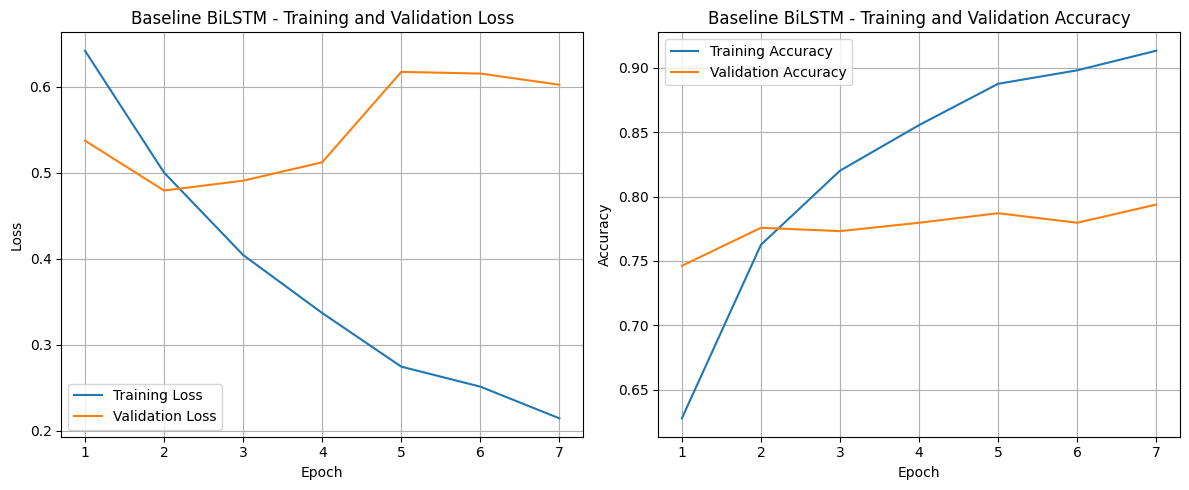

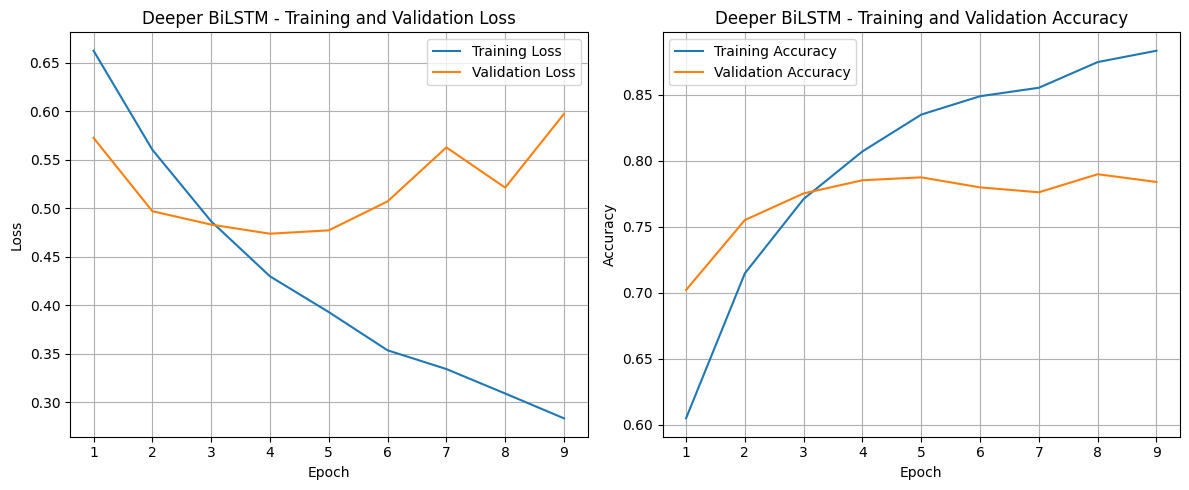

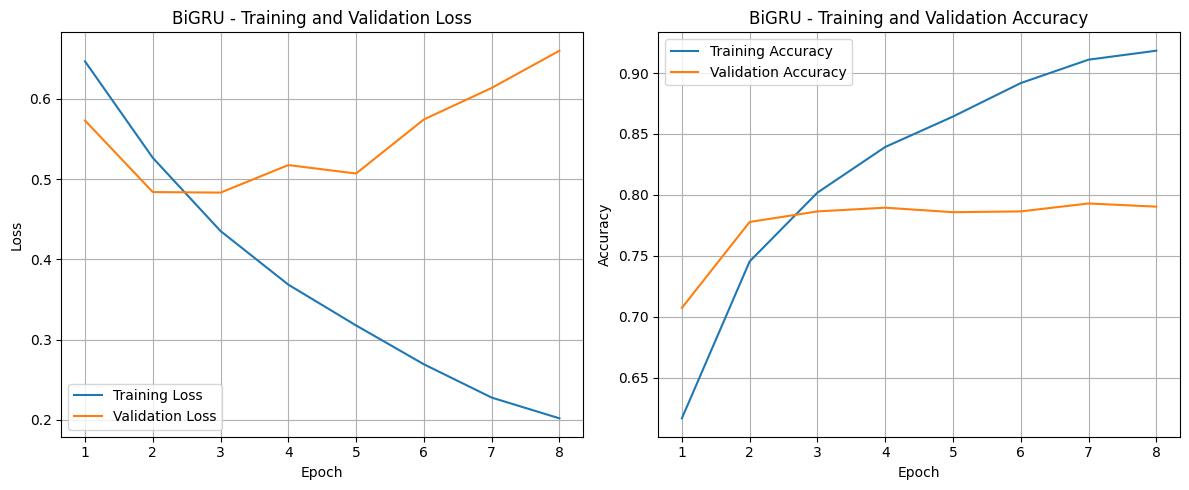

In [38]:
# Function to plot training history
def plot_history(train_losses, val_losses, train_accuracies, val_accuracies, title):
    epochs_range = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label='Training Loss')
    plt.plot(epochs_range, val_losses, label='Validation Loss')
    plt.title(f'{title} - Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
    plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
    plt.title(f'{title} - Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Example usage (run after all models are trained):
plot_history(train_losses_hist, val_losses_hist, train_accuracies_hist, val_accuracies_hist, "Baseline BiLSTM")
plot_history(train_losses_exp2_hist, val_losses_exp2_hist, train_accuracies_exp2_hist, val_accuracies_exp2_hist, "Deeper BiLSTM")
plot_history(train_losses_exp3_hist, val_losses_exp3_hist, train_accuracies_exp3_hist, val_accuracies_exp3_hist, "BiGRU")

## Analysis and Troubleshooting

Each model seemed to perform fairly well with similar levels of success. While the results are consistent over the three models, none of them were extremely accurate, and that could be due to the data cleaning being too strenuous. Relevant words may be getting removed and the tokenization may not be necessary. It would also be worth trying different max length values. 

## Best Architecture

The models, again, were very close in the metrics we calculated. BiGRU achieved the best Validation F1-Score at 0.7270, as well as the best Validation Accuracy which was 0.7859. 

## Future work

Further tuning could involve integrating pre-trained word embeddings (e.g., GloVe, Word2Vec), incorporating keyword/location features, or exploring transformer-based models like BERT for potentially higher performance.

## References


Paszke, A., et al. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. Advances in Neural Information Processing Systems, 32. (PyTorch framework)

Hunter, J. D. (2007). Matplotlib: A 2D Graphics Environment. Computing in Science & Engineering, 9(3), 90-95. (For matplotlib plotting)

Waskom, M. L. (2018). Seaborn: Statistical Data Visualization. Journal of Open Source Software, 3(23), 978. (For seaborn plotting)

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825-2830. (For sklearn metrics and train_test_split)

S. (n.d.). Long Short-Term Memory. Wikipedia. Retrieved from https://en.wikipedia.org/wiki/Long_short-term_memory (For LSTM concepts)

S. (n.d.). Gated Recurrent Unit. Wikipedia. Retrieved from https://en.wikipedia.org/wiki/Gated_recurrent_unit (For GRU concepts)